In [1]:
# import required packages
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from matplotlib import pyplot as plt
from matplotlib import colors as mpc
from sklearn.mixture import GaussianMixture
import pandas as pd
import math
import seaborn as sns; sns.set()
from sklearn.metrics import r2_score 
# from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
# from sklearn.model_selection import KFold
from sklearn import linear_model
# from sklearn.ensemble import RandomForestRegressor
from gmr import GMM #https://alexanderfabisch.github.io/gmr/gmm.html#gmr.gmm.GMM.predict

from IPython.display import clear_output

%load_ext autoreload
%autoreload 
%matplotlib inline

### Define functions for analysis 

In [2]:
# define functions for model evaluation
def n_bias(estimated, true):
    estimated_ = estimated.reshape(estimated.shape[0])
    
    true_ = true.reshape(true.shape[0])
    return np.sum(np.subtract(estimated_, true_))/estimated_.shape[0]

def cvMAE(estimated, true):
    estimated_ = estimated.reshape(estimated.shape[0])
    true_ = true.reshape(true.shape[0])
    return np.sum(abs(np.subtract(estimated_, true_) - n_bias(estimated_, true)))/np.sum(true_)

def mnbias(estimated, true):
    estimated_ = estimated.reshape(estimated.shape[0])
    true_ = true.reshape(true.shape[0])
    return np.sum(np.subtract(estimated_, true_))/np.sum(true_)

def nmae(estimated, true):
    estimated_ = estimated.reshape(estimated.shape[0])
    true_ = true.reshape(true.shape[0])
    return np.sum(np.abs(np.subtract(estimated_, true_)))/np.sum(true_)

## Load day blocked train/test split for ML

In [4]:
# import data
# INSERT PATH TO FILE HERE
path = "/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/calibration/mod_grimm_day_block_split_pm10_20260315.csv"
model_data_dayblock = pd.read_csv(path, header = 0, index_col = 0)

model_data_dayblock.head()

,monitor,date_hour,date,hour,season,sin_hour,cos_hour,season_binary,mod_pm25,mod_pm1,mod_pm10,mod_temp,mod_rh,grimm_pm10,split_day_block
row_id,,,,,,,,,,,,,,,
1,MOD-PM-00884,2025-08-11T15:00:00Z,2025-08-11,15,Not Harmattan,-0.707107,-7.071068e-01,0,28.345801,27.432117,27.278433,29.274333,63.610667,14.376923,train
2,MOD-PM-00884,2025-08-11T16:00:00Z,2025-08-11,16,Not Harmattan,-0.866025,-5.000000e-01,0,26.151898,25.329228,26.324786,29.145333,66.256333,18.105000,train
3,MOD-PM-00884,2025-08-11T17:00:00Z,2025-08-11,17,Not Harmattan,-0.965926,-2.588190e-01,0,54.440715,51.968724,47.903003,29.045472,66.595283,16.336667,train
4,MOD-PM-00884,2025-08-11T18:00:00Z,2025-08-11,18,Not Harmattan,-1.000000,-1.836970e-16,0,38.984314,37.306635,35.711713,28.003400,69.538600,16.188333,train
5,MOD-PM-00884,2025-08-11T19:00:00Z,2025-08-11,19,Not Harmattan,-0.965926,2.588190e-01,0,30.793365,29.665518,29.383296,27.130000,71.385424,28.405000,train


In [5]:
train_ = model_data_dayblock[model_data_dayblock['split_day_block'] == 'train'].copy()
test_  = model_data_dayblock[model_data_dayblock['split_day_block'] == 'test'].copy()

train_ = train_[['mod_pm10', 'mod_temp', 'mod_rh', 'grimm_pm10']]
test_  = test_[['mod_pm10', 'mod_temp', 'mod_rh', 'grimm_pm10']]

train_ = train_.dropna()
test_ = test_.dropna()

model_data_dayblock = model_data_dayblock[['mod_pm10', 'mod_temp', 'mod_rh', 'grimm_pm10']].dropna()

print(train_.shape)
print(test_.shape)

(2410, 4)
(577, 4)


## GMR 1: GMR using PM 10 + temperature + RH

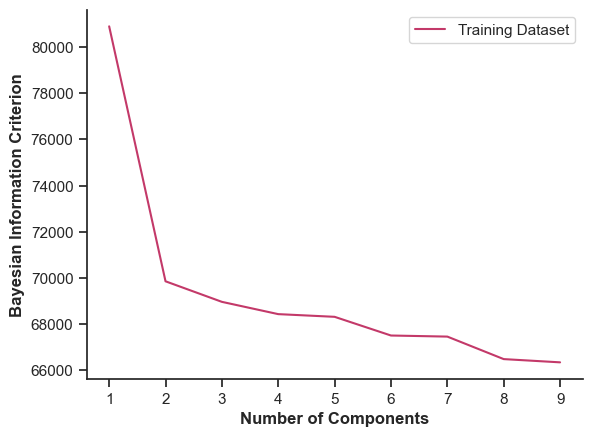

In [6]:
# select models with lowest BIC/AIC
n_components = np.arange(1, 10)
models_train = [GaussianMixture(n, covariance_type = 'full', random_state = 2).fit(train_) for n in n_components]

sns.set_style("ticks", {"xtick.major.size": 7, "ytick.major.size": 7})

plt.plot(n_components, [m.bic(train_) for m in models_train], color = "#C33969", label = 'Training Dataset')
plt.legend(loc = 'upper right')
plt.xlabel('Number of Components', fontweight = 'bold')
plt.ylabel('Bayesian Information Criterion', fontweight = 'bold')

sns.despine()
plt.show()

In [8]:
bic_values = [m.bic(train_) for m in models_train]
best_n = n_components[np.argmin(bic_values)]

print("Best number of components:", 6) ## hard coded 6 instead of using best_n because marginal improvements in BIC

# build GMM with components as suggested by BIC
gmm = GMM(n_components=5, random_state=11)
gmm.from_samples(train_.to_numpy())

# regress test values
Y = gmm.predict(
    np.array([0, 1, 2]),
    test_[["mod_pm10", "mod_temp", "mod_rh"]].to_numpy()
)

y_true = test_["grimm_pm10"].to_numpy()
y_pred = Y.ravel()


rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print('R2: ', r2_score(y_true, y_pred))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('RMSE: ', rmse)
print('Bias: ', n_bias(y_pred, y_true))
print('Bias Corrected Mean Normalized Absolute Error: ', cvMAE(y_pred, y_true))
print('Mean Normalized Bias: ', mnbias(y_pred, y_true))

Best number of components: 6
R2:  0.7476633468831784
MAE:  7.32469226779783
RMSE:  12.271237211264665
Bias:  -0.032563465606503396
Bias Corrected Mean Normalized Absolute Error:  0.2752041578423508
Mean Normalized Bias:  -0.0012228190384707147


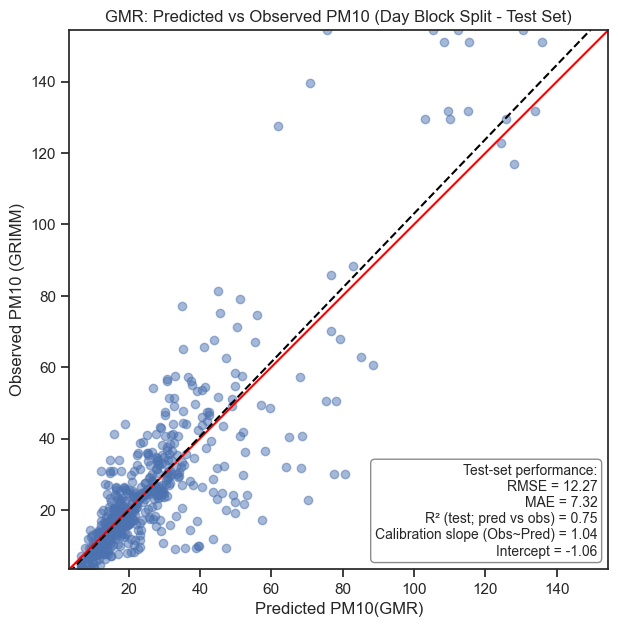

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

# Build test results dataframe
test_results = test_.copy()
test_results["pred_gmr"] = y_pred  # assumes y_pred is your GMR prediction from the test set

# Metrics
rmse_val = np.sqrt(mean_squared_error(test_results["grimm_pm10"], test_results["pred_gmr"]))
mae_val = mean_absolute_error(test_results["grimm_pm10"], test_results["pred_gmr"])
rsq_val = r2_score(test_results["grimm_pm10"], test_results["pred_gmr"])

# Calibration: observed ~ predicted
cal_model = LinearRegression()
X_cal = test_results[["pred_gmr"]]
y_cal = test_results["grimm_pm10"]
cal_model.fit(X_cal, y_cal)

cal_int = cal_model.intercept_
cal_slope = cal_model.coef_[0]

# Shared axis limits
lims = [
    min(test_results["grimm_pm10"].min(), test_results["pred_gmr"].min()),
    max(test_results["grimm_pm10"].max(), test_results["pred_gmr"].max())
]

# Plot
plt.figure(figsize=(7, 7))

# points
plt.scatter(
    test_results["pred_gmr"],
    test_results["grimm_pm10"],
    alpha=0.5
)

# 1:1 line
plt.plot(lims, lims, color="red")

# fitted calibration line
x_line = np.linspace(lims[0], lims[1], 200)
y_line = cal_int + cal_slope * x_line
plt.plot(x_line, y_line, linestyle="dashed", color="black")

# equal axes
plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect('equal', adjustable='box')

# labels and title
plt.title("GMR: Predicted vs Observed PM10 (Day Block Split - Test Set)")
plt.xlabel("Predicted PM10(GMR)")
plt.ylabel("Observed PM10 (GRIMM)")

# annotation box
caption_text = (
    f"Test-set performance:\n"
    f"RMSE = {rmse_val:.2f}\n"
    f"MAE = {mae_val:.2f}\n"
    f"R² (test; pred vs obs) = {rsq_val:.2f}\n"
    f"Calibration slope (Obs~Pred) = {cal_slope:.2f}\n"
    f"Intercept = {cal_int:.2f}"
)

plt.text(
    0.98, 0.02,
    caption_text,
    transform=plt.gca().transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
)

plt.show()

## Missing input analysis

In [11]:
# Missing RH
Y_noRH = gmm.predict(np.array([0, 1]), test_[["mod_pm10", "mod_temp"]].to_numpy())
y_pred = Y_noRH[:, 1]
y_true = test_["grimm_pm10"].to_numpy()

print('conditional GMR prediction with missing RH')
print('R2: ', r2_score(y_true, y_pred))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('Bias: ', n_bias(y_pred, y_true))
print('cvMAE: ', cvMAE(y_pred, y_true))
print('MNB: ', mnbias(y_pred, y_true))


# Missing temperature
Y_notemp = gmm.predict(np.array([0, 2]), test_[["mod_pm10", "mod_rh"]].to_numpy())
y_pred = Y_notemp[:, 1]

print('\nconditional GMR prediction wit missing temperature')
print('R2: ', r2_score(y_true, y_pred))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('Bias: ', n_bias(y_pred, y_true))
print('cvMAE: ', cvMAE(y_pred, y_true))
print('MNB: ', mnbias(y_pred, y_true))


# Missing temperature and RH
Y_justMOD = gmm.predict(np.array([0]), test_[["mod_pm10"]].to_numpy())
y_pred = Y_justMOD[:, 2]

print('\nconditional GMR prediction with missing temperature and RH')
print('R2: ', r2_score(y_true, y_pred))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('Bias: ', n_bias(y_pred, y_true))
print('cvMAE: ', cvMAE(y_pred, y_true))
print('MNB: ', mnbias(y_pred, y_true))

conditional GMR prediction with missing RH
R2:  0.6633562075533482
MAE:  8.075916486731144
Bias:  1.22691762195025
cvMAE:  0.2982787213573948
MNB:  0.04607305146465582

conditional GMR prediction wit missing temperature
R2:  0.7334880415562546
MAE:  7.3819619169200825
Bias:  0.08757668360531001
cvMAE:  0.27678858575285353
MNB:  0.0032886682680762233

conditional GMR prediction with missing temperature and RH
R2:  0.6723430400303525
MAE:  8.165717760723423
Bias:  0.9929444335054164
cvMAE:  0.3021272153820796
MNB:  0.037286920627743324


## GMR Figures

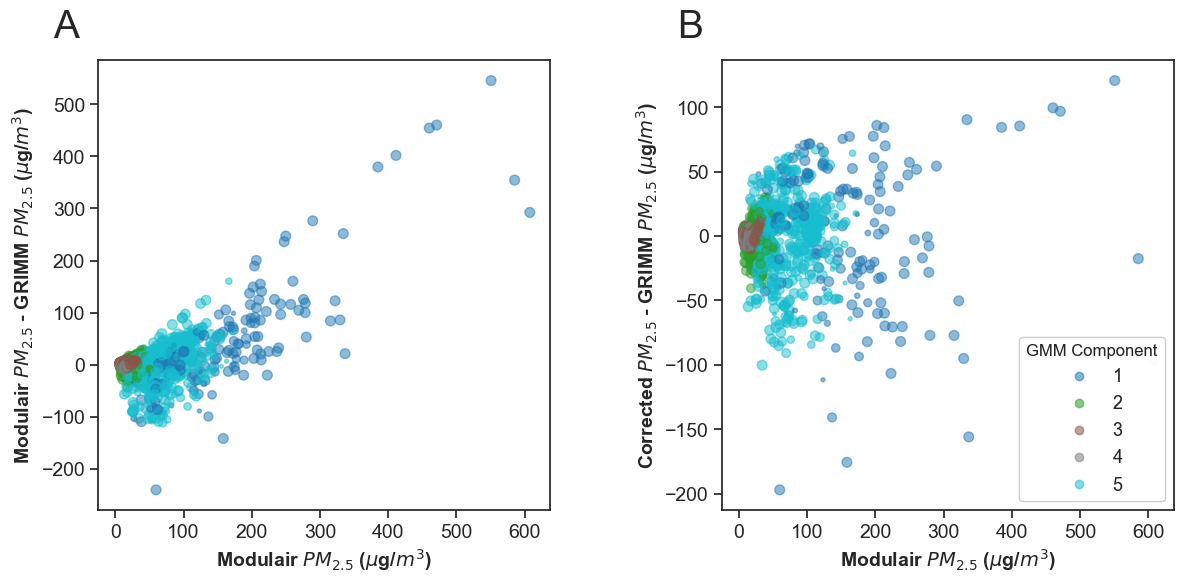

In [12]:
# GMR Figures

# use cleaned modeling data so dimensions match what gmm expects
plot_data = train_[['mod_pm10', 'mod_temp', 'mod_rh', 'grimm_pm10']].dropna().copy()

# get array of responsibilities based on ORIGINAL GMM and not GMR
# each row gives probabilities of belonging to each mixture component
probs = gmm.to_responsibilities(plot_data.to_numpy())
labels = np.argmax(probs, axis=1)

# create size object to visualize responsibilities more easily
size = 50 * probs.max(1) ** 3
legend_values = labels + 1

# get array of raw biases to plot
bias = plot_data["mod_pm10"].to_numpy() - plot_data["grimm_pm10"].to_numpy()

# regress entire data set
Y2 = gmm.predict(
    np.array([0, 1, 2]),
    plot_data[["mod_pm10", "mod_temp", "mod_rh"]].to_numpy()
).ravel()

modelbias = Y2 - plot_data["grimm_pm10"].to_numpy()

# set color map
colors = plt.cm.get_cmap('tab10', best_n)

sns.set_style("ticks", {"xtick.major.size": 7, "ytick.major.size": 7})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(
    plot_data["mod_pm10"],
    bias,
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.set_xlabel('Modulair $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight='bold', fontsize=14)
ax1.set_ylabel('Modulair $PM_{2.5}$ - GRIMM $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight='bold', fontsize=14)
ax1.text(-0.1, 1.05, "A", transform=ax1.transAxes, size=28)

scatterb = ax2.scatter(
    plot_data["mod_pm10"],
    modelbias,
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax2.set_xlabel('Modulair $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight='bold', fontsize=14)
ax2.set_ylabel('Corrected $PM_{2.5}$ - GRIMM $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight='bold', fontsize=14)
ax2.text(-0.1, 1.05, "B", transform=ax2.transAxes, size=28)

legend2 = ax2.legend(
    *scatterb.legend_elements(),
    loc='best',
    title="GMM Component",
    fontsize=13
)
ax2.add_artist(legend2)
plt.setp(legend2.get_title(), fontsize=12)

fig.tight_layout(w_pad=5)
plt.show()

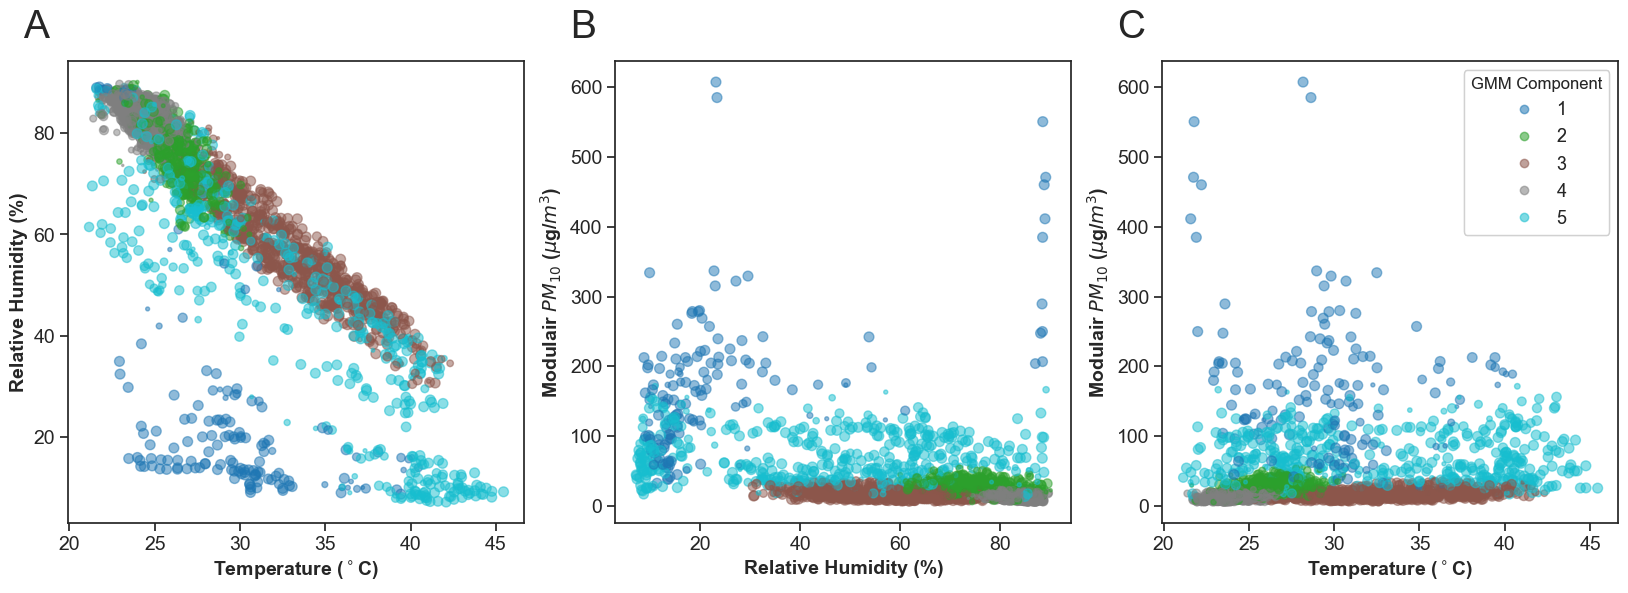

In [14]:

sns.set_style("ticks", {"xtick.major.size": 7, "ytick.major.size": 7})
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.scatter(
    plot_data["mod_temp"],
    plot_data["mod_rh"],
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.set_xlabel('Temperature ($^\\circ$C)', fontweight='bold', fontsize=14)
ax1.set_ylabel('Relative Humidity (%)', fontweight='bold', fontsize=14)
ax1.text(-0.1, 1.05, "A", transform=ax1.transAxes, size=28)

ax2.scatter(
    plot_data["mod_rh"],
    plot_data["mod_pm10"],
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax2.set_ylabel('Modulair $PM_{10}$ ($\\mu$g/$m^3$)', fontweight='bold', fontsize=14)
ax2.set_xlabel('Relative Humidity (%)', fontweight='bold', fontsize=14)
ax2.text(-0.1, 1.05, "B", transform=ax2.transAxes, size=28)

scatter3 = ax3.scatter(
    plot_data["mod_temp"],
    plot_data["mod_pm10"],
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax3.tick_params(axis='x', labelsize=14)
ax3.tick_params(axis='y', labelsize=14)
ax3.set_ylabel('Modulair $PM_{10}$ ($\\mu$g/$m^3$)', fontweight='bold', fontsize=14)
ax3.set_xlabel('Temperature ($^\\circ$C)', fontweight='bold', fontsize=14)
ax3.text(-0.1, 1.05, "C", transform=ax3.transAxes, size=28)

legend3 = ax3.legend(
    *scatter3.legend_elements(),
    loc='best',
    title="GMM Component",
    fontsize=13
)
ax3.add_artist(legend3)
plt.setp(legend3.get_title(), fontsize=12)

plt.show()

## GMR 2: GMR using PM2.5 + temperature + RH + cyclical hour + seasons

### Day block train/test split

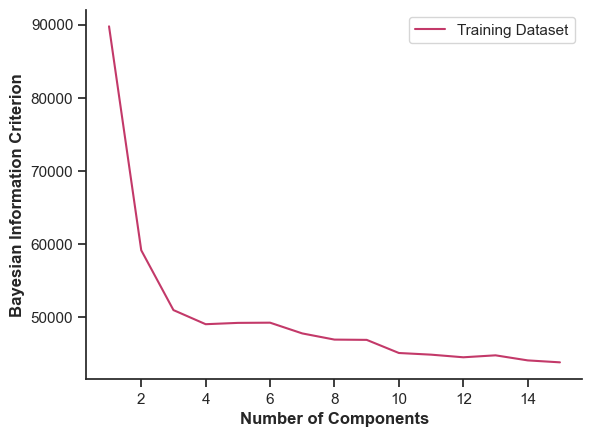

In [15]:
# import data
path = "/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/calibration/mod_grimm_day_block_split_pm10_20260315.csv"
model_data_dayblock = pd.read_csv(path, header=0, index_col=0)

# make sure season is numeric for GMM
model_data_dayblock["season_binary"] = np.where(model_data_dayblock["season"] == "Harmattan", 1, 0)

train_ = model_data_dayblock[model_data_dayblock["split_day_block"] == "train"].copy()
test_  = model_data_dayblock[model_data_dayblock["split_day_block"] == "test"].copy()

train_ = train_[["mod_pm10", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary", "grimm_pm10"]]
test_  = test_[["mod_pm10", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary", "grimm_pm10"]]

train_ = train_.dropna()
test_ = test_.dropna()

model_data_dayblock_clean = model_data_dayblock[["mod_pm10", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary", "grimm_pm10"]].dropna()

# select models with lowest BIC/AIC
n_components = np.arange(1, 16)
models_train = [
    GaussianMixture(n, covariance_type="full", random_state=2).fit(train_)
    for n in n_components
]

sns.set_style("ticks", {"xtick.major.size": 7, "ytick.major.size": 7})

plt.plot(
    n_components,
    [m.bic(train_) for m in models_train],
    color="#C33969",
    label="Training Dataset"
)
plt.legend(loc="upper right")
plt.xlabel("Number of Components", fontweight="bold")
plt.ylabel("Bayesian Information Criterion", fontweight="bold")
sns.despine()
plt.show()

In [20]:
bic_values = [m.bic(train_) for m in models_train]
best_n = 4 # hard code based on plot

print("Best number of components:", best_n)

# build GMM with components as suggested by BIC
gmm = GMM(n_components=best_n, random_state=11)
gmm.from_samples(train_.to_numpy())

# regress test values
Y = gmm.predict(
    np.array([0, 1, 2, 3, 4, 5]),
    test_[["mod_pm10", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary" ]].to_numpy()
)

y_true = test_["grimm_pm10"].to_numpy()
y_pred = Y.ravel()


rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print('R2: ', r2_score(y_true, y_pred))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('RMSE: ', rmse)
print('Bias: ', n_bias(y_pred, y_true))
print('Bias Corrected Mean Normalized Absolute Error: ', cvMAE(y_pred, y_true))
print('Mean Normalized Bias: ', mnbias(y_pred, y_true))

Best number of components: 4
R2:  0.7291650736399042
MAE:  8.242725454199665
RMSE:  12.713072300373112
Bias:  1.0816288796440952
Bias Corrected Mean Normalized Absolute Error:  0.3043799488510379
Mean Normalized Bias:  0.04061718745084673


Normalized RMSE percent:  47.73996427224935


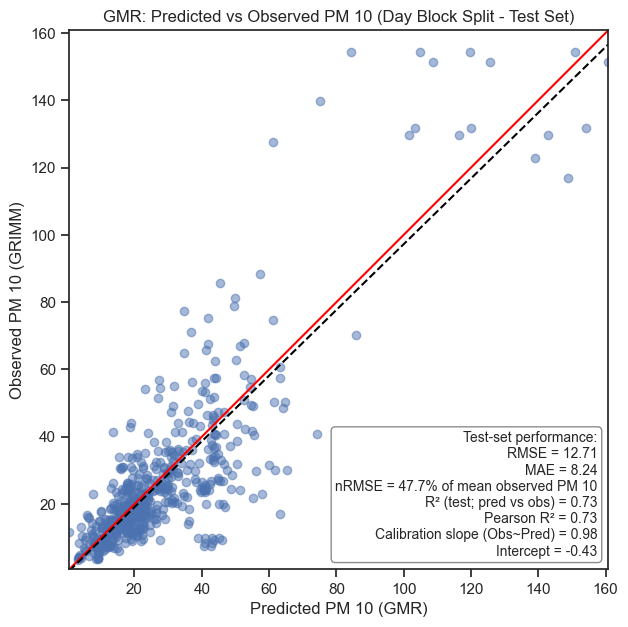

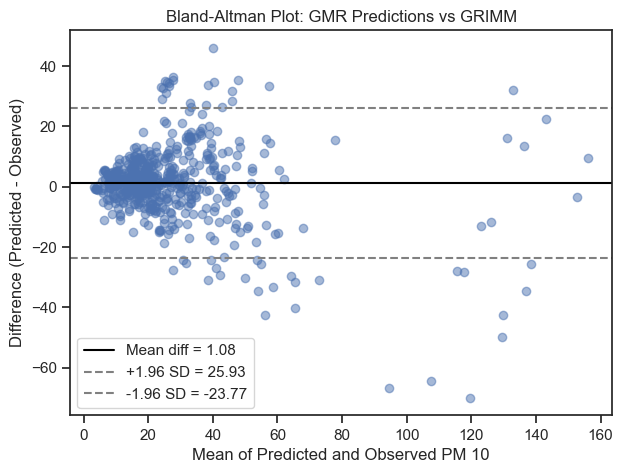

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

# Build test results dataframe
test_results = test_.copy()
test_results["pred_gmr"] = y_pred  # assumes y_pred is your GMR prediction from the test set

# Metrics
rmse_val = np.sqrt(mean_squared_error(test_results["grimm_pm10"], test_results["pred_gmr"]))
mae_val = mean_absolute_error(test_results["grimm_pm10"], test_results["pred_gmr"])
rsq_val = r2_score(test_results["grimm_pm10"], test_results["pred_gmr"])

# Optional: Pearson R^2 if you want to match what you were doing in R
pearson_r2 = np.corrcoef(test_results["grimm_pm10"], test_results["pred_gmr"])[0, 1] ** 2

# Normalized RMSE (% of mean observed PM2.5)
mean_obs = test_results["grimm_pm10"].mean()
nrmse_pct = 100 * rmse_val / mean_obs

print('Normalized RMSE percent: ', nrmse_pct)


# Calibration: observed ~ predicted
cal_model = LinearRegression()
X_cal = test_results[["pred_gmr"]]
y_cal = test_results["grimm_pm10"]
cal_model.fit(X_cal, y_cal)

cal_int = cal_model.intercept_
cal_slope = cal_model.coef_[0]

# Shared axis limits
lims = [
    min(test_results["grimm_pm10"].min(), test_results["pred_gmr"].min()),
    max(test_results["grimm_pm10"].max(), test_results["pred_gmr"].max())
]

# Predicted vs observed plot
plt.figure(figsize=(7, 7))

plt.scatter(
    test_results["pred_gmr"],
    test_results["grimm_pm10"],
    alpha=0.5
)

# 1:1 line
plt.plot(lims, lims, color="red")

# fitted calibration line
x_line = np.linspace(lims[0], lims[1], 200)
y_line = cal_int + cal_slope * x_line
plt.plot(x_line, y_line, linestyle="dashed", color="black")

plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect("equal", adjustable="box")

plt.title("GMR: Predicted vs Observed PM 10 (Day Block Split - Test Set)")
plt.xlabel("Predicted PM 10 (GMR)")
plt.ylabel("Observed PM 10 (GRIMM)")

caption_text = (
    f"Test-set performance:\n"
    f"RMSE = {rmse_val:.2f}\n"
    f"MAE = {mae_val:.2f}\n"
    f"nRMSE = {nrmse_pct:.1f}% of mean observed PM 10\n"
    f"R² (test; pred vs obs) = {rsq_val:.2f}\n"
    f"Pearson R² = {pearson_r2:.2f}\n"
    f"Calibration slope (Obs~Pred) = {cal_slope:.2f}\n"
    f"Intercept = {cal_int:.2f}"
)

plt.text(
    0.98, 0.02,
    caption_text,
    transform=plt.gca().transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
)

plt.show()

# -----------------------------
# Bland-Altman plot
# -----------------------------
test_results["ba_mean"] = (test_results["pred_gmr"] + test_results["grimm_pm10"]) / 2
test_results["ba_diff"] = test_results["pred_gmr"] - test_results["grimm_pm10"]

mean_diff = test_results["ba_diff"].mean()
sd_diff = test_results["ba_diff"].std()

loa_upper = mean_diff + 1.96 * sd_diff
loa_lower = mean_diff - 1.96 * sd_diff

plt.figure(figsize=(7, 5))

plt.scatter(
    test_results["ba_mean"],
    test_results["ba_diff"],
    alpha=0.5
)

plt.axhline(mean_diff, linestyle="-", color="black", label=f"Mean diff = {mean_diff:.2f}")
plt.axhline(loa_upper, linestyle="dashed", color="gray", label=f"+1.96 SD = {loa_upper:.2f}")
plt.axhline(loa_lower, linestyle="dashed", color="gray", label=f"-1.96 SD = {loa_lower:.2f}")

plt.title("Bland-Altman Plot: GMR Predictions vs GRIMM")
plt.xlabel("Mean of Predicted and Observed PM 10")
plt.ylabel("Difference (Predicted - Observed)")

plt.legend()
plt.show()

### missing input analysis 

In [22]:
# Missing RH
Y_noRH = gmm.predict(
    np.array([0, 1, 3, 4, 5]),
    test_[["mod_pm10", "mod_temp", "sin_hour", "cos_hour", "season_binary"]].to_numpy()
)
y_pred = Y_noRH[:, 1]

y_true = test_["grimm_pm10"].to_numpy()

print('conditional GMR prediction with missing RH')
print('R2: ', r2_score(y_true, y_pred))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('Bias: ', n_bias(y_pred, y_true))
print('cvMAE: ', cvMAE(y_pred, y_true))
print('MNB: ', mnbias(y_pred, y_true))


# Missing temperature
Y_notemp = gmm.predict(
    np.array([0, 2, 3, 4, 5]),
    test_[["mod_pm10", "mod_rh", "sin_hour", "cos_hour", "season_binary"]].to_numpy()
)
y_pred = Y_notemp[:, 1]

print('\nconditional GMR prediction wit missing temperature')
print('R2: ', r2_score(y_true, y_pred))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('Bias: ', n_bias(y_pred, y_true))
print('cvMAE: ', cvMAE(y_pred, y_true))
print('MNB: ', mnbias(y_pred, y_true))


# Missing temperature and RH
Y_justMOD = gmm.predict(
    np.array([0, 3, 4, 5]),
    test_[["mod_pm10", "sin_hour", "cos_hour", "season_binary"]].to_numpy()
)
y_pred = Y_justMOD[:, 2]

print('\nconditional GMR prediction with missing temperature and RH')
print('R2: ', r2_score(y_true, y_pred))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('Bias: ', n_bias(y_pred, y_true))
print('cvMAE: ', cvMAE(y_pred, y_true))
print('MNB: ', mnbias(y_pred, y_true))

conditional GMR prediction with missing RH
R2:  0.6415083423344148
MAE:  9.291937108422937
Bias:  1.678708784863976
cvMAE:  0.34427229874761694
MNB:  0.06303865463784493

conditional GMR prediction wit missing temperature
R2:  0.7110253335697883
MAE:  8.471990934484356
Bias:  1.118677379893802
cvMAE:  0.3142846779742947
MNB:  0.04200842792873618

conditional GMR prediction with missing temperature and RH
R2:  0.6370579538899823
MAE:  9.449396568378068
Bias:  1.9637606207857543
cvMAE:  0.3502969750585119
MNB:  0.0737428842222589


## GMR figures

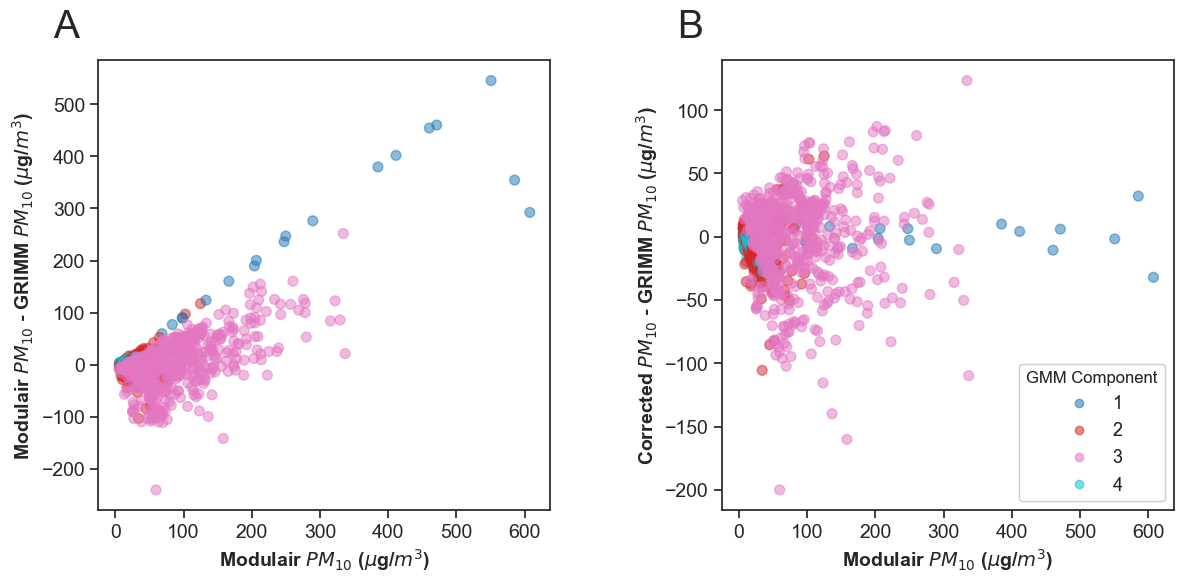

In [23]:
# GMR Figures

fit_cols = ["mod_pm10", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary", "grimm_pm10"]

# use cleaned TRAINING data so dimensions match what gmm expects
plot_data = train_[fit_cols].dropna().copy()

# get array of responsibilities based on ORIGINAL GMM
# each row gives probabilities of belonging to each mixture component
probs = gmm.to_responsibilities(plot_data.to_numpy())
labels = np.argmax(probs, axis=1)

# create size object to visualize responsibilities more easily
size = 50 * probs.max(1) ** 3
legend_values = labels + 1

# get array of raw biases to plot
bias = plot_data["mod_pm10"].to_numpy() - plot_data["grimm_pm10"].to_numpy()

# regress entire training data set using all predictors except outcome
Y2 = gmm.predict(
    np.array([0, 1, 2, 3, 4, 5]),
    plot_data[["mod_pm10", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary"]].to_numpy()
).ravel()

modelbias = Y2 - plot_data["grimm_pm10"].to_numpy()

# set color map
colors = plt.cm.get_cmap("tab10", best_n)

sns.set_style("ticks", {"xtick.major.size": 7, "ytick.major.size": 7})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(
    plot_data["mod_pm10"],
    bias,
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)
ax1.set_xlabel('Modulair $PM_{10}$ ($\\mu$g/$m^3$)', fontweight="bold", fontsize=14)
ax1.set_ylabel('Modulair $PM_{10}$ - GRIMM $PM_{10}$ ($\\mu$g/$m^3$)', fontweight="bold", fontsize=14)
ax1.text(-0.1, 1.05, "A", transform=ax1.transAxes, size=28)

scatterb = ax2.scatter(
    plot_data["mod_pm10"],
    modelbias,
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax2.tick_params(axis="x", labelsize=14)
ax2.tick_params(axis="y", labelsize=14)
ax2.set_xlabel('Modulair $PM_{10}$ ($\\mu$g/$m^3$)', fontweight="bold", fontsize=14)
ax2.set_ylabel('Corrected $PM_{10}$ - GRIMM $PM_{10}$ ($\\mu$g/$m^3$)', fontweight="bold", fontsize=14)
ax2.text(-0.1, 1.05, "B", transform=ax2.transAxes, size=28)

legend2 = ax2.legend(
    *scatterb.legend_elements(),
    loc="best",
    title="GMM Component",
    fontsize=13
)
ax2.add_artist(legend2)
plt.setp(legend2.get_title(), fontsize=12)

fig.tight_layout(w_pad=5)
plt.show()

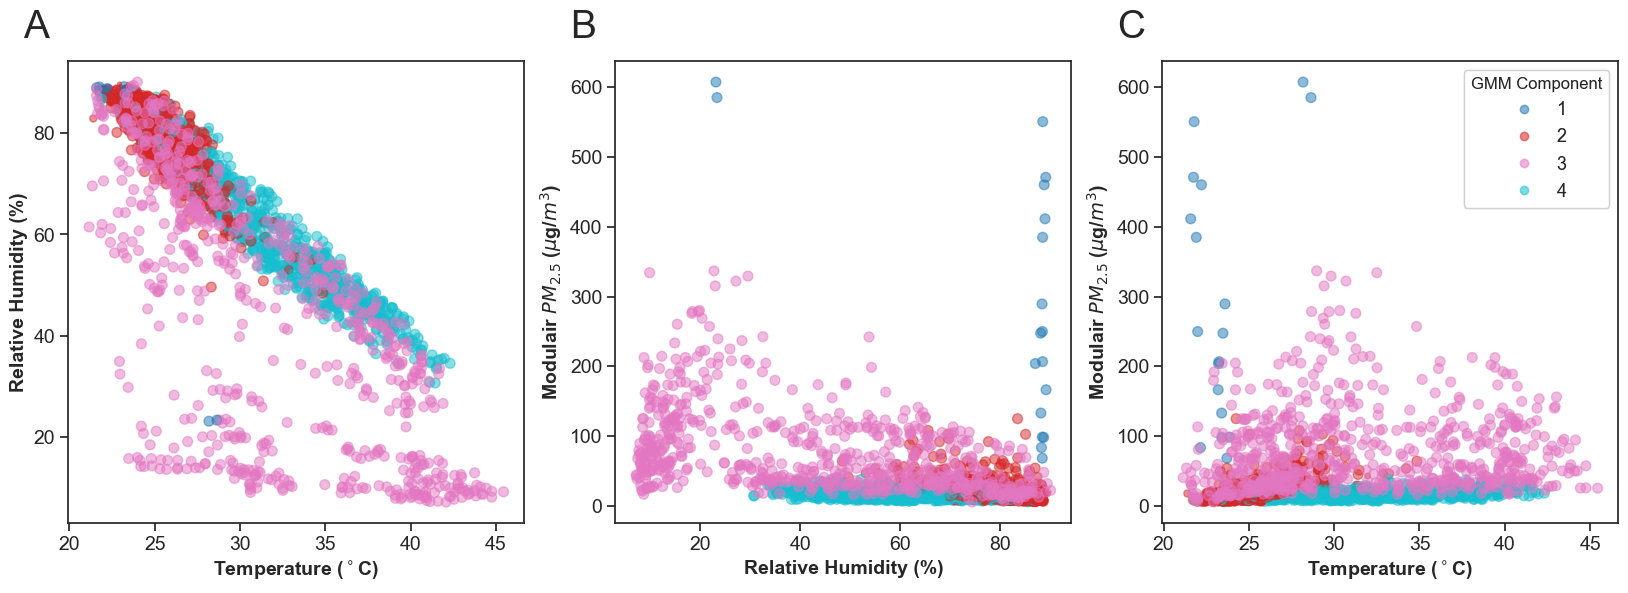

In [25]:
sns.set_style("ticks", {"xtick.major.size": 7, "ytick.major.size": 7})
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.scatter(
    plot_data["mod_temp"],
    plot_data["mod_rh"],
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)
ax1.set_xlabel('Temperature ($^\\circ$C)', fontweight="bold", fontsize=14)
ax1.set_ylabel('Relative Humidity (%)', fontweight="bold", fontsize=14)
ax1.text(-0.1, 1.05, "A", transform=ax1.transAxes, size=28)

ax2.scatter(
    plot_data["mod_rh"],
    plot_data["mod_pm10"],
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax2.tick_params(axis="x", labelsize=14)
ax2.tick_params(axis="y", labelsize=14)
ax2.set_ylabel('Modulair $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight="bold", fontsize=14)
ax2.set_xlabel('Relative Humidity (%)', fontweight="bold", fontsize=14)
ax2.text(-0.1, 1.05, "B", transform=ax2.transAxes, size=28)

scatter3 = ax3.scatter(
    plot_data["mod_temp"],
    plot_data["mod_pm10"],
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax3.tick_params(axis="x", labelsize=14)
ax3.tick_params(axis="y", labelsize=14)
ax3.set_ylabel('Modulair $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight="bold", fontsize=14)
ax3.set_xlabel('Temperature ($^\\circ$C)', fontweight="bold", fontsize=14)
ax3.text(-0.1, 1.05, "C", transform=ax3.transAxes, size=28)

legend3 = ax3.legend(
    *scatter3.legend_elements(),
    loc="best",
    title="GMM Component",
    fontsize=13
)
ax3.add_artist(legend3)
plt.setp(legend3.get_title(), fontsize=12)

plt.show()

### Save model (saved the one with hour and season)

In [27]:
import pickle
from pathlib import Path

fit_cols = ["mod_pm10", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary", "grimm_pm10"]
x_cols = ["mod_pm10", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary"]

full_calibration = model_data_dayblock[fit_cols].dropna().copy()

gmm_final = GMM(n_components=4, random_state=11)
gmm_final.from_samples(full_calibration.to_numpy())

# save fitted model
model_outpath = Path("/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/calibration/gmr_dayblock_final_pm10.pkl")
with open(model_outpath, "wb") as f:
    pickle.dump(gmm_final, f)

print(f"Saved model to: {model_outpath}")

Saved model to: /Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/calibration/gmr_dayblock_final_pm10.pkl


#### Load and prepare full Modulair data

In [30]:
import numpy as np
import pandas as pd

# INSERT PATHS
pm10_1 = pd.read_csv("/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/pm/summarized/pm10_community_hourly_20231024-20240816.csv")
pm10_2 = pd.read_csv("/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/pm/summarized/pm10_community_hourly_20241031-20250901.csv")
temp_1 = pd.read_csv("/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/weather/summarized/temp_hourly_20230815-20240820.csv")
temp_2 = pd.read_csv("/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/weather/summarized/temp_hourly_20241031-20250901.csv")
rh_1   = pd.read_csv("/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/weather/summarized/rh_hourly_20230815-20240820.csv")
rh_2   = pd.read_csv("/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/weather/summarized/rh_hourly_20241031-20250901.csv")

pm10 = pd.concat([pm10_1, pm10_2], ignore_index=True)
temp = pd.concat([temp_1, temp_2], ignore_index=True)
rh   = pd.concat([rh_1, rh_2], ignore_index=True)

pm10 = pm10.loc[pm10["mean_pm10"].notna()].copy()
temp = temp.loc[temp["mean_met_temp"].notna()].copy()
rh   = rh.loc[rh["mean_met_rh"].notna()].copy()

# drop extra columns if present
for df, cols in [
    (pm10, ["n_minute_obs", "n_active", "fleet_average_pm25"]),
    (temp, ["n_minute_obs", "n_active", "fleet_average_met_temp"]),
    (rh,   ["n_minute_obs", "n_active", "fleet_average_met_rh"]),
]:
    drop_cols = [c for c in cols if c in df.columns]
    df.drop(columns=drop_cols, inplace=True)

modulair_full = (
    pm10.merge(temp, on=["monitor", "date", "hour"], how="outer")
        .merge(rh, on=["monitor", "date", "hour"], how="outer")
)

modulair_full["date"] = pd.to_datetime(modulair_full["date"])
modulair_full["date_hour"] = pd.to_datetime(
    modulair_full["date"].dt.strftime("%Y-%m-%d") + " " + modulair_full["hour"].astype(int).astype(str) + ":00:00",
    utc=True
)

modulair_full = modulair_full.rename(columns={
    "mean_pm10": "mod_pm10",
    "mean_met_temp": "mod_temp",
    "mean_met_rh": "mod_rh"
})

modulair_full["month"] = modulair_full["date"].dt.month
modulair_full["season_binary"] = np.where(modulair_full["month"].isin([12, 1, 2]), 1, 0)
modulair_full["sin_hour"] = np.sin(2 * np.pi * modulair_full["hour"] / 24)
modulair_full["cos_hour"] = np.cos(2 * np.pi * modulair_full["hour"] / 24)

# require predictors used by GMR
pred_cols = ["mod_pm10", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary"]
modulair_apply = modulair_full.dropna(subset=pred_cols).copy()

print(modulair_apply.shape)
modulair_apply.head()

(328356, 12)


,monitor,date,hour,mod_pm10,fleet_average_pm10,mod_temp,mod_rh,date_hour,month,season_binary,sin_hour,cos_hour
0,MOD-00077,2024-10-31,0.0,45.456667,19.867143,25.703333,82.776667,2024-10-31 00:00:00+00:00,10,0,0.000000,1.000000
1,MOD-00077,2024-10-31,1.0,31.430167,19.837614,25.303333,83.910000,2024-10-31 01:00:00+00:00,10,0,0.258819,0.965926
2,MOD-00077,2024-10-31,2.0,28.708333,19.005298,24.958333,85.163333,2024-10-31 02:00:00+00:00,10,0,0.500000,0.866025
3,MOD-00077,2024-10-31,3.0,39.851333,17.234998,24.740000,86.226667,2024-10-31 03:00:00+00:00,10,0,0.707107,0.707107
4,MOD-00077,2024-10-31,4.0,32.428833,18.498885,24.708333,86.286667,2024-10-31 04:00:00+00:00,10,0,0.866025,0.500000


#### Apply saved GMR model

In [31]:
with open("/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/calibration/gmr_dayblock_final_pm10.pkl", "rb") as f:
    gmm_loaded = pickle.load(f)

X_full = modulair_apply[["mod_pm10", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary"]].to_numpy()

Y_full = gmm_loaded.predict(
    np.array([0, 1, 2, 3, 4, 5]),
    X_full
).ravel()

modulair_apply["pm10_fem_gmr"] = np.maximum(Y_full, 0)
modulair_apply["delta_gmr"] = modulair_apply["pm10_fem_gmr"] - modulair_apply["mod_pm10"]
modulair_apply["ratio_gmr"] = np.where(
    modulair_apply["mod_pm10"] > 0,
    modulair_apply["pm10_fem_gmr"] / modulair_apply["mod_pm10"],
    np.nan
)

modulair_apply.head()

,monitor,date,hour,mod_pm10,fleet_average_pm10,mod_temp,mod_rh,date_hour,month,season_binary,sin_hour,cos_hour,pm10_fem_gmr,delta_gmr,ratio_gmr
0,MOD-00077,2024-10-31,0.0,45.456667,19.867143,25.703333,82.776667,2024-10-31 00:00:00+00:00,10,0,0.000000,1.000000,24.667266,-20.789400,0.542655
1,MOD-00077,2024-10-31,1.0,31.430167,19.837614,25.303333,83.910000,2024-10-31 01:00:00+00:00,10,0,0.258819,0.965926,22.369373,-9.060794,0.711717
2,MOD-00077,2024-10-31,2.0,28.708333,19.005298,24.958333,85.163333,2024-10-31 02:00:00+00:00,10,0,0.500000,0.866025,21.454897,-7.253437,0.747340
3,MOD-00077,2024-10-31,3.0,39.851333,17.234998,24.740000,86.226667,2024-10-31 03:00:00+00:00,10,0,0.707107,0.707107,20.862740,-18.988593,0.523514
4,MOD-00077,2024-10-31,4.0,32.428833,18.498885,24.708333,86.286667,2024-10-31 04:00:00+00:00,10,0,0.866025,0.500000,19.367950,-13.060884,0.597245


#### Save calibrated full data

In [ ]:
# outpath = "/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/all_measurements/summarized/modulair_full_calibrated_gmr.csv"
# modulair_apply.to_csv(outpath, index=False)
# print(f"Saved calibrated data to: {outpath}")

#### Raw vs calibrated plot

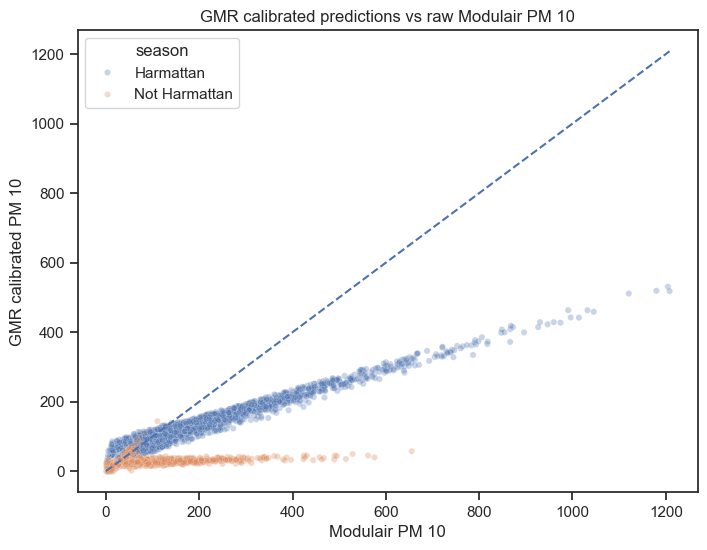

In [32]:
plot_df = modulair_apply.sample(n=min(10000, len(modulair_apply)), random_state=123).copy()
plot_df["season"] = np.where(plot_df["season_binary"] == 1, "Harmattan", "Not Harmattan")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="mod_pm10", y="pm10_fem_gmr", hue="season", alpha=0.3, s=20)
lims = [
    min(plot_df["mod_pm10"].min(), plot_df["pm10_fem_gmr"].min()),
    max(plot_df["mod_pm10"].max(), plot_df["pm10_fem_gmr"].max())
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Modulair PM 10")
plt.ylabel("GMR calibrated PM 10")
plt.title("GMR calibrated predictions vs raw Modulair PM 10")
plt.show()

#### Calibration change by monitor

In [33]:
monitor_summary = (
    modulair_apply.groupby("monitor")
    .agg(
        n=("mod_pm10", "size"),
        mean_raw=("mod_pm10", "mean"),
        mean_gmr=("pm10_fem_gmr", "mean"),
        mean_delta_gmr=("delta_gmr", "mean"),
        median_ratio_gmr=("ratio_gmr", "median")
    )
    .reset_index()
)

# round columns
monitor_summary = monitor_summary.round({
    "mean_raw": 2,
    "mean_gmr": 2,
    "mean_delta_gmr": 2,
    "median_ratio_gmr": 2
})

# sort
monitor_summary = monitor_summary.sort_values(
    "mean_delta_gmr", key=np.abs, ascending=False
)

monitor_summary

,monitor,n,mean_raw,mean_gmr,mean_delta_gmr,median_ratio_gmr
61,MOD-PM-01089,1236,192.98,111.64,-81.34,0.64
4,MOD-00400,8874,149.74,74.09,-75.65,0.69
24,MOD-PM-00892,2253,163.89,88.62,-75.27,0.62
19,MOD-PM-00887,4538,131.21,56.76,-74.44,0.65
52,MOD-PM-01080,1306,191.09,121.01,-70.08,0.70
...,...,...,...,...,...,...
34,MOD-PM-01052,10428,44.06,35.23,-8.83,0.97
41,MOD-PM-01059,9278,45.35,38.42,-6.93,0.96
29,MOD-PM-00897,6293,36.66,31.73,-4.93,0.94
17,MOD-PM-00885,1968,38.77,36.16,-2.61,0.98


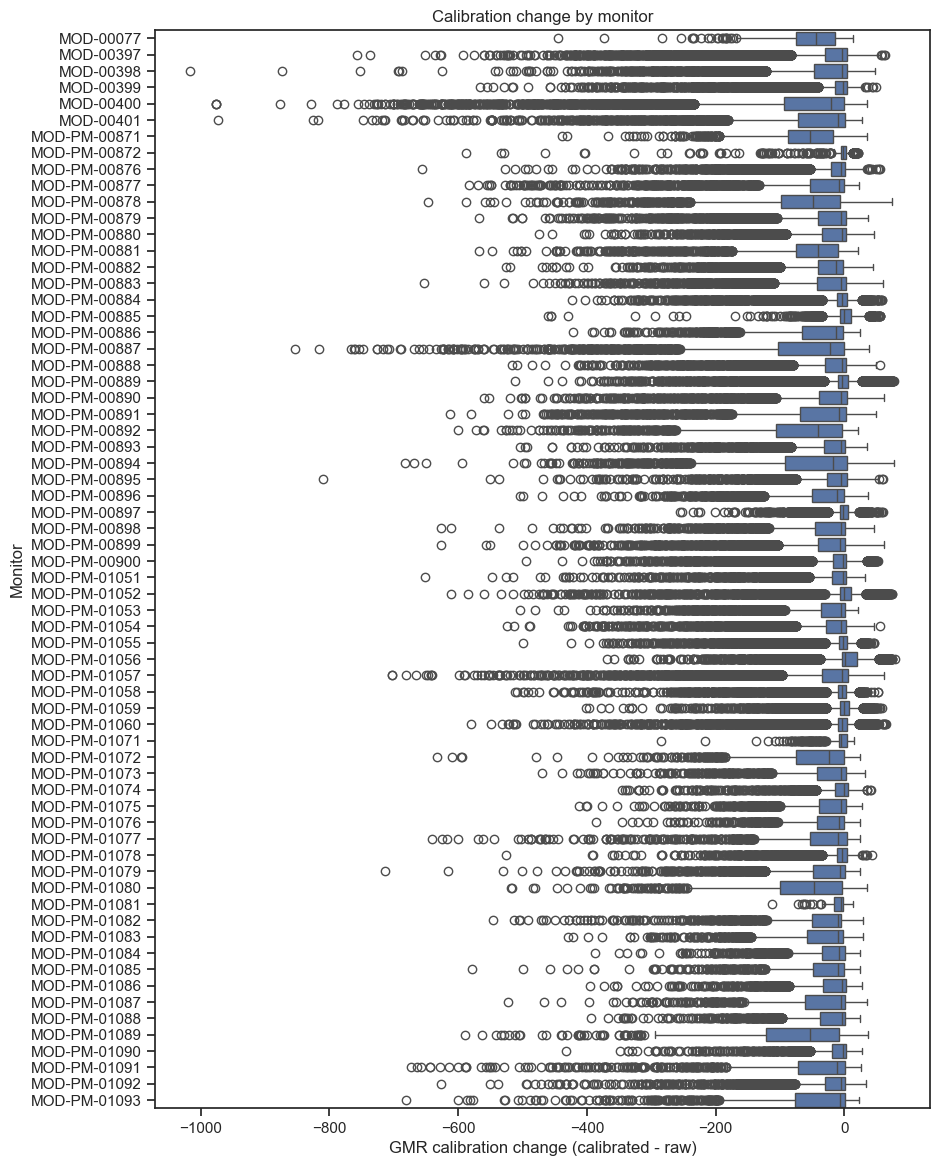

In [34]:
plt.figure(figsize=(10, 14))
sns.boxplot(data=modulair_apply, x="delta_gmr", y="monitor")
plt.xlabel("GMR calibration change (calibrated - raw)")
plt.ylabel("Monitor")
plt.title("Calibration change by monitor")
plt.show()

#### Calibration change vs RH

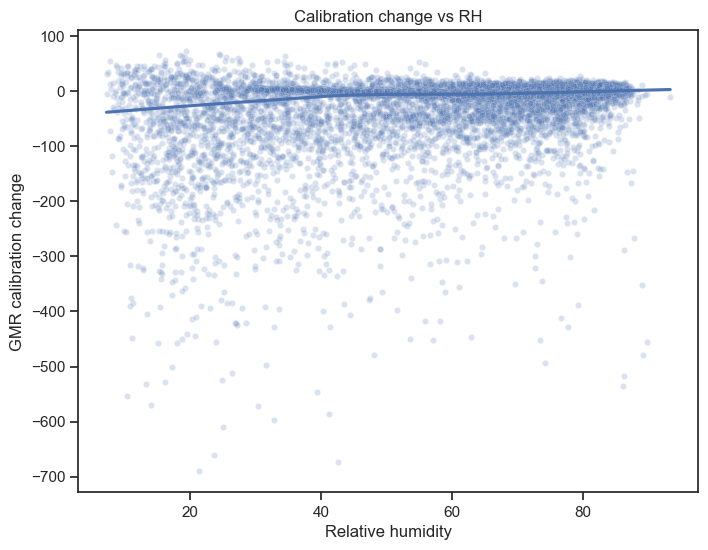

In [35]:
plot_df = modulair_apply.sample(n=min(10000, len(modulair_apply)), random_state=123)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="mod_rh", y="delta_gmr", alpha=0.2, s=20)
sns.regplot(data=plot_df, x="mod_rh", y="delta_gmr", scatter=False, lowess=True)
plt.xlabel("Relative humidity")
plt.ylabel("GMR calibration change")
plt.title("Calibration change vs RH")
plt.show()

#### Calibration change vs temperature

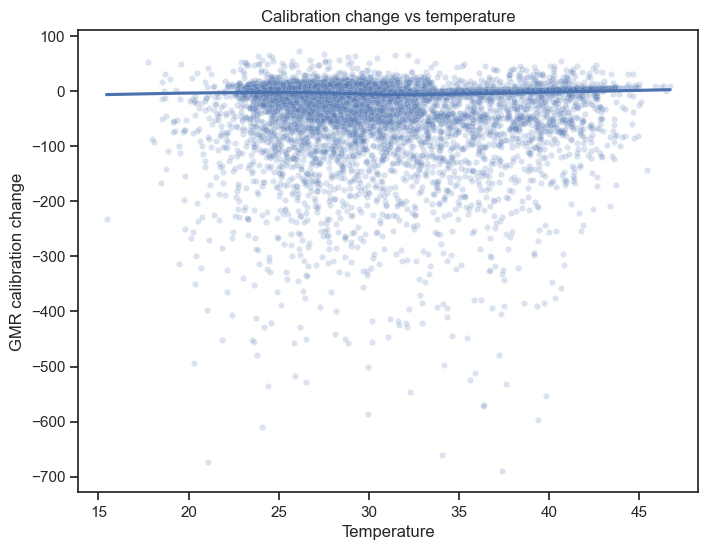

In [36]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="mod_temp", y="delta_gmr", alpha=0.2, s=20)
sns.regplot(data=plot_df, x="mod_temp", y="delta_gmr", scatter=False, lowess=True)
plt.xlabel("Temperature")
plt.ylabel("GMR calibration change")
plt.title("Calibration change vs temperature")
plt.show()